### Whisper Beam Search

#### インポート

In [1]:
from whisper.tokenizer import get_tokenizer
from whisper import load_model, load_audio

model = load_model("large-v3-turbo", device="cuda")
model.eval()

tokenizer = get_tokenizer(multilingual=True, task="transcribe")

In [5]:
from whisper.tokenizer import get_tokenizer
from whisper import load_model, load_audio
import os
import pandas as pd
import matplotlib.pyplot as plt
from whisper.decoding import BeamSearchDecoder
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from typing import Tuple
import random
import numpy as np
import torch
import torch.nn.functional as F

session_number =2
condition = "右前"
extension = "wav"
beam_size = 3

from src import get_path  
mov_path = get_path(session_number, condition, extension)
print(mov_path)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

0604data/2回目_右前.wav


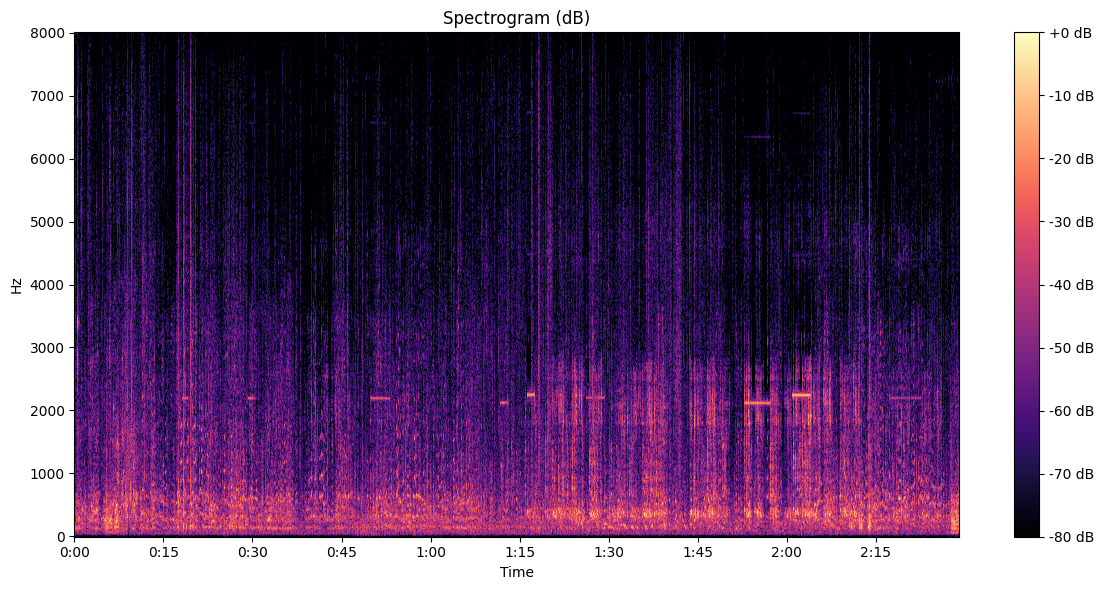

In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 音声ファイル読み込み（Whisperと同じ16kHzで）
y, sr = librosa.load(str(mov_path), sr=16000)

# スペクトログラム（STFT）計算
D = librosa.stft(y, n_fft=1024, hop_length=256)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# プロット
plt.figure(figsize=(12, 6))
librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (dB)")
plt.tight_layout()
plt.show()


In [6]:
import numpy as np
import scipy.signal as signal
import librosa
import torch
from whisper import load_audio, load_model

# 🔧 ノイズ除去関数（バンドパスフィルタ）
def denoise_audio(y: np.ndarray, sr: int) -> np.ndarray:
    # 300Hz〜3400Hz の音声帯域だけを残す（電話音声品質の典型例）
    sos = signal.butter(10, [300, 3400], btype='bandpass', fs=sr, output='sos')
    filtered = signal.sosfilt(sos, y)
    return filtered

# 🔄 Whisper推論用：ノイズ除去つき音声読み込み
y, sr = librosa.load(str(mov_path), sr=16000)     # whisperは16kHzが推奨
y = denoise_audio(y, sr)                           # ノイズ除去
audio = torch.tensor(y).float()                   # Whisper用にfloat32に変換

# 🔎 推論（モデル名や beam_size はそのまま）
result = model.transcribe(audio.numpy(), beam_size=beam_size)

print("\n=== 最終テキスト（ノイズ除去後）===")
print(result["text"])



=== 最終テキスト（ノイズ除去後）===
ご視聴ありがとうございましたご視聴ありがとうございましたご視聴ありがとうございましたご視聴ありがとうございましたご視聴ありがとうございました


In [2]:
from whisper.decoding import BeamSearchDecoder
from src.beam_hook import beam_update, beam_log, step
from src import beam_hook
beam_hook.step = 0
beam_hook.beam_log.clear()

BeamSearchDecoder.update = beam_update

In [ ]:
audio = load_audio(str(mov_path))
result = model.transcribe(audio, beam_size=beam_size,initial_prompt = "傷病者 感染防御 胸骨圧迫")#,temperature=1)

print("\n=== 最終テキスト ===")
print(result["text"])


=== 最終テキスト ===
消防医者が発見、周囲の確認用紙、安全確認用紙、感染防御に配慮します大丈夫ですか、大丈夫ですか、大丈夫ですか、意識がありません誰か来てくださいあなたは119等番、あなたはADをお願いします必ずここに戻ってきてください逆、呼吸ともにありませんさらに呼吸、胸骨アップとお返しますAEDの使い方は分かりますかいや、分かりません私がAEDをやるので、虚構断発を12-3で変わってください分かりました1、2、3パッドを胸に装着してくださいランプが点滅しているソケットにパッドのコネクタを接続してくださいパッドを装着してくださいパッドを装着してくださいコネクタを接続してください心電図を解析中です心電図を解析中です体に触れないでください触れないでくださいショックが必要です充電中です体から離れてください離れてくださいショックを実行しますオレンジボタンをショックが完了しました一時中断中です直ちに胸の発泡と実行呼吸をしてください受けたいです10分前にこの人が倒れているところを発見しました身元は浮かびません腸骨圧迫とETを行いましたご視聴ありがとうございましたその点に5月の予定ですご視聴ありがとうございましたご視聴ありがとうございましたはい、続きます


In [5]:
log_df = pd.DataFrame(beam_log)
print("\n=== 📝 Beam Log の先頭 ===")
print(log_df.head())

# ファイル保存
os.makedirs("outputs/beam_search/steps", exist_ok=True)
csv_path = f"outputs/beam_search/steps/beam_search_steps_{condition}_{session_number}.csv"
log_df.to_csv(csv_path, index=False)
print(f"✅ 保存: {csv_path}")


output_lines = []

df = pd.read_csv(csv_path)
for step in sorted(df["step"].unique()):
    output_lines.append(f"Step {step}:")
    df_step = df[df["step"] == step]
    for _, row in df_step.iterrows():
        line = f"  Beam {row.beam} ← Beam {row.source_beam}: {row.prefix} + 「{row.next_token_str}」 → {row.new_seq}  (score: {row.score:.2f})"
        output_lines.append(line)
    output_lines.append("")  # 改行

# テキスト保存
txt_path = f"outputs/beam_search/steps/beam_trace_output_{condition}_{session_number}.txt"
with open(txt_path, "w", encoding="utf-8") as f:
    f.write("\n".join(output_lines))

print(f"✅ テキスト出力: {txt_path}")


=== 📝 Beam Log の先頭 ===
   step  beam  source_beam                                    prefix  \
0     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   
1     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   
2     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   
3     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   
4     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   

   next_token next_token_str                                   new_seq  \
0       50365                 <|startoftranscript|><|ja|><|startoflm|>   
1       50415                 <|startoftranscript|><|ja|><|startoflm|>   
2       50366                 <|startoftranscript|><|ja|><|startoflm|>   
3       50370                 <|startoftranscript|><|ja|><|startoflm|>   
4       50367                 <|startoftranscript|><|ja|><|startoflm|>   

      score  
0 -0.015239  
1 -6.882915  
2 -7.086040  
3 -7.410259  
4 -7.414165  
✅ 保存: beam_sea

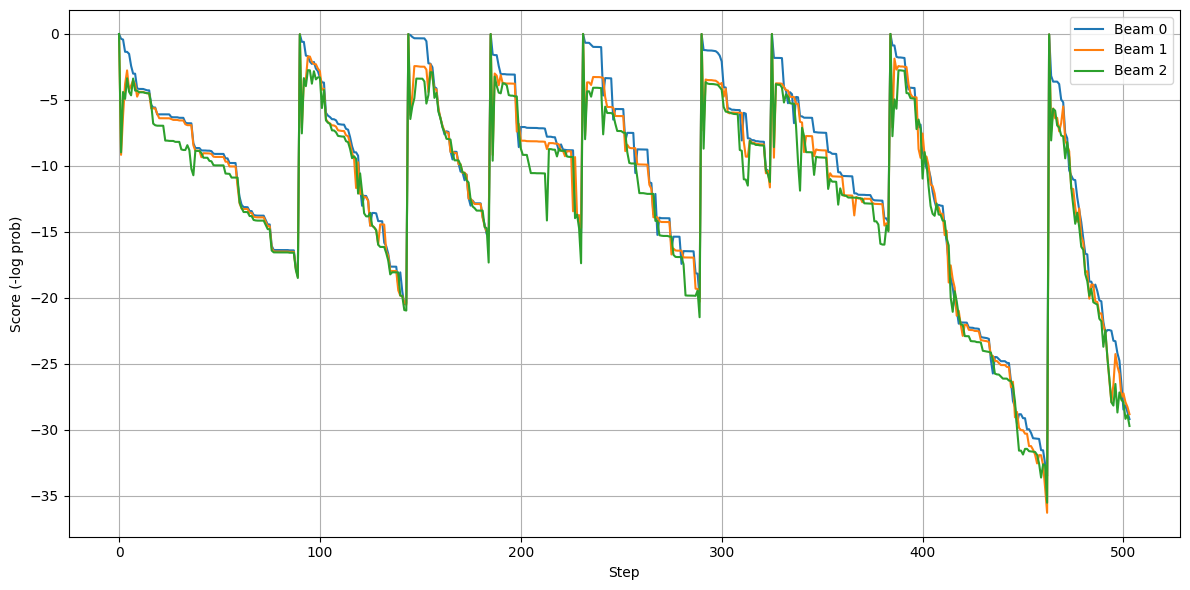

In [6]:
# ===============================
# 🔸8. スコア推移の可視化
# ===============================
# 各 step × beam ごとに最良スコアのものを抽出
best_per_beam = (
    log_df.sort_values("score", ascending=False)
    .groupby(["step", "beam"])
    .first()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for beam_id in best_per_beam["beam"].unique():
    df_beam = best_per_beam[best_per_beam["beam"] == beam_id]
    plt.plot(df_beam["step"], df_beam["score"], label=f"Beam {beam_id}")

plt.xlabel("Step")
plt.ylabel("Score (-log prob)")
plt.xlim()
plt.legend()
plt.grid(True)
plt.tight_layout()
# 🔽 PNGファイルとして保存
os.makedirs("outputs/beam_search/plots", exist_ok=True)
plt.savefig(f"outputs/beam_search/plots/beam_score_{condition}_{session_number}.png", dpi=300)
plt.show()

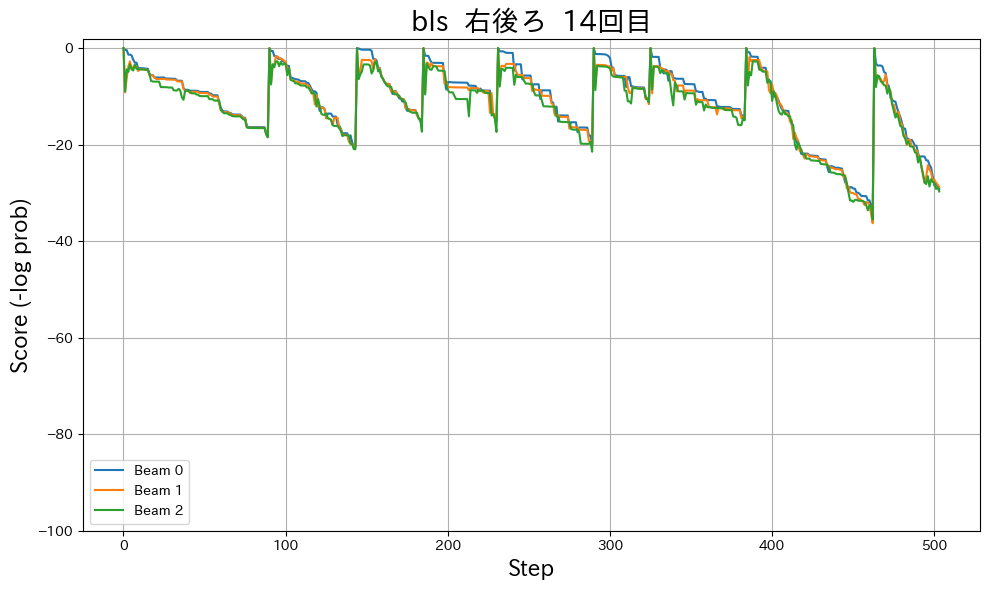

✅ PNG保存: beam_log_右後ろ_14.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# condition ="右後ろ"
# session_number = 3
csv_path = f"outputs/beam_search/steps/beam_search_steps_{condition}_{session_number}.csv"

df = pd.read_csv(csv_path)


best_per_beam = (
    df.sort_values("score", ascending=False)
    .groupby(["step", "beam"])
    .first()
    .reset_index()
)

# グラフ描画
plt.figure(figsize=(10, 6))
for beam_id in best_per_beam["beam"].unique():
    df_beam = best_per_beam[best_per_beam["beam"] == beam_id]
    plt.plot(df_beam["step"], df_beam["score"], label=f"Beam {beam_id}")

plt.xlabel("Step", fontsize=16)
plt.ylabel("Score (-log prob)", fontsize=16)
plt.ylim(-100,)
plt.title(f"bls  {condition}  {session_number}回目", fontsize=20)
plt.legend()
plt.grid(True)
plt.tight_layout()

# 🔽 PNGファイルとして保存
os.makedirs("outputs/beam_search/plots", exist_ok=True)
png_path = f"outputs/beam_search/plots/beam_log_{condition}_{session_number}.png"
plt.savefig(png_path, dpi=300)
plt.show()

print(f"✅ PNG保存: {png_path}")
